## Neural Machine Translation

## Objective
Implement a complete **machine translation system** translating
**English → Spanish** using an LSTM-based encoder-decoder with attention.

## Requirements
- Choose language pair: **English → Spanish**
- Use parallel corpus (curated / synthetic WMT-style)
- Implement Transformer-based or LSTM-based model
- Add attention mechanism
- Implement beam search
- Calculate BLEU scores

## Deliverables
1. Trained model achieving BLEU > 25
2. Translation examples with attention visualization
3. Error analysis on test set
4. Comparison of different attention mechanisms
5. Discussion of challenges and solutions

## Architecture
```
English sentence → [Encoder: BiLSTM] → Hidden States
                                            ↓
                         [Attention: Bahdanau / Luong / MultiHead]
                                            ↓
                    [Decoder: LSTM] → Spanish sentence
```

## 1. Setup and Imports

Libraries used:
- **PyTorch** – model building, training, GPU acceleration
- **NLTK** – BLEU score computation (the standard MT evaluation metric)
- **Matplotlib / Seaborn** – training curves, attention heatmaps
- **NumPy** – numerical utilities

In [46]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
import random
import math
import time
import warnings
warnings.filterwarnings('ignore')

# BLEU score
try:
    from nltk.translate.bleu_score import sentence_bleu, corpus_bleu, SmoothingFunction
    import nltk
    nltk.download('punkt', quiet=True)
    nltk.download('punkt_tab', quiet=True)
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'nltk', '-q'])
    from nltk.translate.bleu_score import sentence_bleu, corpus_bleu, SmoothingFunction
    import nltk
    nltk.download('punkt', quiet=True)
    nltk.download('punkt_tab', quiet=True)

# ── Device & Seeds ──
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

print(f'Device: {device}')
print('Setup complete ✓')

Device: cpu
Setup complete ✓


## 2. Parallel Corpus: English → Spanish

We create a curated **parallel corpus** of 500+ English-Spanish sentence pairs
covering everyday topics. Each pair is an aligned translation.

The dataset is designed so that:
- Sentences are short (5–15 words) → tractable for LSTM training
- Vocabulary is ~400 words per language
- Spanish grammatical features (gender, verb conjugation, flexible word order) are represented
- Common grammatical patterns repeat to aid learning

In a production setting, you would use **WMT** or **EuroParl** (millions of
EN/ES pairs). Our curated dataset lets us train quickly and
focus on the architecture.

In [47]:
# ══════════════════════════════════════════════════════════════════════
#  ENGLISH-SPANISH PARALLEL CORPUS
#  Each tuple: (english_sentence, spanish_translation)
# ══════════════════════════════════════════════════════════════════════

parallel_corpus = [
    # ── Greetings & Daily ──
    ("hello how are you", "hola como estas"),
    ("good morning", "buenos dias"),
    ("good evening", "buenas tardes"),
    ("good night", "buenas noches"),
    ("thank you very much", "muchas gracias"),
    ("you are welcome", "de nada"),
    ("excuse me please", "disculpe por favor"),
    ("see you later", "hasta luego"),
    ("goodbye", "adios"),
    ("nice to meet you", "encantado de conocerte"),
    ("how is it going", "como te va"),
    ("i am fine thanks", "estoy bien gracias"),
    ("have a nice day", "que tengas un buen dia"),
    ("welcome to spain", "bienvenido a espana"),
    ("what is your name", "como te llamas"),
    ("my name is john", "mi nombre es john"),
    ("where are you from", "de donde eres"),
    ("i am from america", "soy de america"),
    ("i speak english", "yo hablo ingles"),
    ("do you speak spanish", "hablas espanol"),

    # ── Animals ──
    ("the cat is small", "el gato es pequeno"),
    ("the dog is big", "el perro es grande"),
    ("the bird can fly", "el pajaro puede volar"),
    ("the fish swims in water", "el pez nada en el agua"),
    ("i have a cat", "yo tengo un gato"),
    ("she has a dog", "ella tiene un perro"),
    ("the horse runs fast", "el caballo corre rapido"),
    ("the rabbit is white", "el conejo es blanco"),
    ("birds sing in the morning", "los pajaros cantan por la manana"),
    ("the mouse is very small", "el raton es muy pequeno"),

    # ── Food & Drink ──
    ("i am hungry", "tengo hambre"),
    ("i am thirsty", "tengo sed"),
    ("the food is good", "la comida es buena"),
    ("i like coffee", "me gusta el cafe"),
    ("she drinks tea", "ella bebe te"),
    ("we eat bread", "nosotros comemos pan"),
    ("the water is cold", "el agua esta fria"),
    ("i want an apple", "quiero una manzana"),
    ("the cake is delicious", "el pastel esta delicioso"),
    ("he cooks dinner", "el cocina la cena"),
    ("the milk is fresh", "la leche esta fresca"),
    ("i eat rice every day", "como arroz todos los dias"),
    ("the soup is hot", "la sopa esta caliente"),
    ("we need more salt", "necesitamos mas sal"),
    ("the cheese is from france", "el queso es de francia"),

    # ── Family ──
    ("the mother loves her children", "la madre ama a sus hijos"),
    ("my father works hard", "mi padre trabaja duro"),
    ("my sister is young", "mi hermana es joven"),
    ("my brother is tall", "mi hermano es alto"),
    ("the family is happy", "la familia es feliz"),
    ("i love my parents", "yo amo a mis padres"),
    ("the baby is sleeping", "el bebe esta durmiendo"),
    ("we visit our grandparents", "visitamos a nuestros abuelos"),
    ("the children play outside", "los ninos juegan afuera"),
    ("she has two daughters", "ella tiene dos hijas"),

    # ── Colors & Descriptions ──
    ("the sky is blue", "el cielo es azul"),
    ("the flower is red", "la flor es roja"),
    ("the grass is green", "la hierba es verde"),
    ("the sun is yellow", "el sol es amarillo"),
    ("the car is black", "el coche es negro"),
    ("the house is white", "la casa es blanca"),
    ("the book is old", "el libro es viejo"),
    ("the tree is tall", "el arbol es alto"),
    ("the river is long", "el rio es largo"),
    ("the mountain is high", "la montana es alta"),

    # ── Actions ──
    ("i read a book", "yo leo un libro"),
    ("she writes a letter", "ella escribe una carta"),
    ("he plays football", "el juega futbol"),
    ("we go to school", "vamos a la escuela"),
    ("they come from berlin", "ellos vienen de berlin"),
    ("i learn spanish", "yo aprendo espanol"),
    ("she sings a song", "ella canta una cancion"),
    ("he drives a car", "el conduce un coche"),
    ("we swim in the lake", "nadamos en el lago"),
    ("they dance together", "ellos bailan juntos"),
    ("i sleep at night", "yo duermo por la noche"),
    ("she runs every morning", "ella corre cada manana"),
    ("he watches television", "el mira la television"),
    ("we listen to music", "escuchamos musica"),
    ("they study at the university", "ellos estudian en la universidad"),

    # ── Weather ──
    ("it is raining today", "hoy esta lloviendo"),
    ("the sun is shining", "el sol esta brillando"),
    ("it is very cold", "hace mucho frio"),
    ("the wind is strong", "el viento es fuerte"),
    ("it will snow tomorrow", "manana va a nevar"),
    ("the weather is nice", "el clima esta bonito"),
    ("it is warm outside", "hace calor afuera"),
    ("the sky is cloudy", "el cielo esta nublado"),

    # ── Travel & Places ──
    ("where is the train station", "donde esta la estacion de tren"),
    ("i need a ticket", "necesito un boleto"),
    ("the hotel is nice", "el hotel es bonito"),
    ("we fly to berlin", "volamos a berlin"),
    ("the museum is closed", "el museo esta cerrado"),
    ("the city is beautiful", "la ciudad es hermosa"),
    ("we take the bus", "tomamos el autobus"),
    ("the airport is far", "el aeropuerto esta lejos"),
    ("i want to visit madrid", "quiero visitar madrid"),
    ("spain is a beautiful country", "espana es un pais hermoso"),

    # ── Numbers & Time ──
    ("it is three o clock", "son las tres"),
    ("i have two brothers", "tengo dos hermanos"),
    ("there are five books", "hay cinco libros"),
    ("the class starts at eight", "la clase empieza a las ocho"),
    ("i work eight hours", "trabajo ocho horas"),
    ("today is monday", "hoy es lunes"),
    ("the month has thirty days", "el mes tiene treinta dias"),

    # ── Questions ──
    ("how much does it cost", "cuanto cuesta"),
    ("where is the bathroom", "donde esta el bano"),
    ("when does the train leave", "cuando sale el tren"),
    ("who is that person", "quien es esa persona"),
    ("why are you late", "por que llegas tarde"),
    ("what time is it", "que hora es"),
    ("can you help me", "puedes ayudarme"),
    ("do you understand me", "me entiendes"),
    ("what does that mean", "que significa eso"),
    ("how old are you", "cuantos anos tienes"),

    # ── Negation ──
    ("i do not understand", "no entiendo"),
    ("he does not know", "el no sabe"),
    ("we do not have time", "no tenemos tiempo"),
    ("she is not here", "ella no esta aqui"),
    ("they do not speak english", "ellos no hablan ingles"),
    ("i cannot come today", "no puedo venir hoy"),
    ("the shop is not open", "la tienda no esta abierta"),

    # ── Complex sentences ──
    ("i think that is a good idea", "creo que es una buena idea"),
    ("she said she will come tomorrow", "ella dijo que vendra manana"),
    ("we should go home now", "deberiamos ir a casa ahora"),
    ("he wants to learn spanish", "el quiere aprender espanol"),
    ("the teacher explains the lesson", "el profesor explica la leccion"),
    ("i need to buy some food", "necesito comprar algo de comida"),
    ("she is reading a newspaper", "ella esta leyendo un periodico"),
    ("we are going to the park", "vamos al parque"),
    ("the students are in the classroom", "los estudiantes estan en el aula"),
    ("he works in a hospital", "el trabaja en un hospital"),
    ("i like to travel in summer", "me gusta viajar en verano"),
    ("the movie starts at seven", "la pelicula empieza a las siete"),
    ("she plays the piano very well", "ella toca el piano muy bien"),
    ("we have a big garden", "tenemos un jardin grande"),
    ("the shop is around the corner", "la tienda esta a la vuelta"),

    # ── More daily life ──
    ("i go to work every day", "voy al trabajo todos los dias"),
    ("she studies medicine", "ella estudia medicina"),
    ("the train arrives at ten", "el tren llega a las diez"),
    ("he lives in a small town", "el vive en un pueblo pequeno"),
    ("we celebrate christmas in december", "celebramos navidad en diciembre"),
    ("the library has many books", "la biblioteca tiene muchos libros"),
    ("i drink water every day", "bebo agua todos los dias"),
    ("the children go to school", "los ninos van a la escuela"),
    ("he bought a new computer", "el compro una computadora nueva"),
    ("we enjoyed the concert", "disfrutamos el concierto"),
    ("she is a good doctor", "ella es una buena doctora"),
    ("the market opens early", "el mercado abre temprano"),
    ("i like swimming in summer", "me gusta nadar en verano"),
    ("they built a new bridge", "ellos construyeron un puente nuevo"),
    ("the restaurant serves italian food", "el restaurante sirve comida italiana"),

    # ── Feelings & Opinions ──
    ("i am very happy today", "estoy muy feliz hoy"),
    ("she is tired from work", "ella esta cansada del trabajo"),
    ("he is afraid of spiders", "el tiene miedo a las aranas"),
    ("we are excited about the trip", "estamos emocionados por el viaje"),
    ("the exam was very difficult", "el examen fue muy dificil"),
    ("i hope the weather is good", "espero que el clima sea bueno"),
    ("she believes in hard work", "ella cree en el trabajo duro"),
    ("the city has a lot of history", "la ciudad tiene mucha historia"),
    ("i enjoy learning new languages", "disfruto aprender nuevos idiomas"),
    ("the view from here is amazing", "la vista desde aqui es increible"),
]

# ── Augment with "please/por favor" variants ──
augmented = []
for en, es in parallel_corpus:
    augmented.append((en, es))
    # Add a slight variant: "please" prefix
    if len(en.split()) > 3 and not en.startswith('please'):
        augmented.append(("please " + en, "por favor " + es))

parallel_corpus = augmented

print(f'Total parallel sentence pairs: {len(parallel_corpus)}')
print(f'\nSamples:')
for i in range(5):
    print(f'  EN: {parallel_corpus[i][0]}')
    print(f'  ES: {parallel_corpus[i][1]}')
    print()

Total parallel sentence pairs: 303

Samples:
  EN: hello how are you
  ES: hola como estas

  EN: please hello how are you
  ES: por favor hola como estas

  EN: good morning
  ES: buenos dias

  EN: good evening
  ES: buenas tardes

  EN: good night
  ES: buenas noches



In [48]:
# ══════════════════════════════════════════════════════════════════════
#  EXTENDED PARALLEL CORPUS
#  ~200 additional sentence pairs for broader vocabulary and grammar
#  coverage. More training data is the #1 way to reduce overfitting
#  and improve BLEU scores with a small curated dataset.
# ══════════════════════════════════════════════════════════════════════

extra_pairs = [
    # ── More Greetings & Social ──
    ("i am glad to see you", "me alegro de verte"),
    ("long time no see", "cuanto tiempo sin verte"),
    ("take care of yourself", "cuidate mucho"),
    ("see you tomorrow", "hasta manana"),
    ("see you soon", "hasta pronto"),
    ("please come in", "por favor pase"),
    ("call me later", "llamame mas tarde"),
    ("i will miss you", "te voy a extranar"),
    ("have a good trip", "buen viaje"),
    ("happy birthday to you", "feliz cumpleanos"),

    # ── More Family ──
    ("my grandmother is old", "mi abuela es mayor"),
    ("his grandfather is wise", "su abuelo es sabio"),
    ("the uncle lives far away", "el tio vive lejos"),
    ("my aunt cooks very well", "mi tia cocina muy bien"),
    ("we have a big family", "tenemos una familia grande"),
    ("the parents are proud", "los padres estan orgullosos"),
    ("my son is at school", "mi hijo esta en la escuela"),
    ("her daughter plays piano", "su hija toca el piano"),

    # ── More Food & Drink ──
    ("the bread is fresh", "el pan esta fresco"),
    ("i eat breakfast every morning", "desayuno todas las mananas"),
    ("she drinks orange juice", "ella bebe jugo de naranja"),
    ("the pizza is very hot", "la pizza esta muy caliente"),
    ("he orders a beer", "el pide una cerveza"),
    ("the ice cream is sweet", "el helado es dulce"),
    ("we buy vegetables at the market", "compramos verduras en el mercado"),
    ("the restaurant is full", "el restaurante esta lleno"),
    ("i cook every day", "cocino todos los dias"),
    ("the wine is from italy", "el vino es de italia"),
    ("she bakes a cake", "ella hornea un pastel"),
    ("the fruit is ripe", "la fruta esta madura"),
    ("the coffee is very strong", "el cafe es muy fuerte"),
    ("we need more water", "necesitamos mas agua"),
    ("the tea is too hot", "el te esta muy caliente"),

    # ── More Animals ──
    ("the elephant is huge", "el elefante es enorme"),
    ("the cow gives milk", "la vaca da leche"),
    ("the sheep is white", "la oveja es blanca"),
    ("the lion is dangerous", "el leon es peligroso"),
    ("we have three cats", "tenemos tres gatos"),
    ("the dog barks loudly", "el perro ladra fuerte"),
    ("the butterfly is colorful", "la mariposa es colorida"),
    ("the pig is fat", "el cerdo es gordo"),

    # ── More Actions ──
    ("i open the door", "yo abro la puerta"),
    ("she closes the window", "ella cierra la ventana"),
    ("he cleans the room", "el limpia la habitacion"),
    ("we wash the dishes", "lavamos los platos"),
    ("they build a house", "ellos construyen una casa"),
    ("i write an email", "yo escribo un correo"),
    ("she draws a picture", "ella dibuja un cuadro"),
    ("he fixes the car", "el repara el coche"),
    ("we plant flowers in spring", "plantamos flores en primavera"),
    ("they sell books", "ellos venden libros"),
    ("i carry the heavy bag", "llevo la bolsa pesada"),
    ("she teaches young children", "ella ensena a ninos pequenos"),
    ("he paints the wall white", "el pinta la pared de blanco"),
    ("we wait for the bus", "esperamos el autobus"),
    ("they cross the street", "ellos cruzan la calle"),
    ("i forget the name", "olvido el nombre"),
    ("she helps her friend", "ella ayuda a su amiga"),
    ("he finds the key", "el encuentra la llave"),
    ("i call my mother", "llamo a mi madre"),
    ("we move to madrid next week", "nos mudamos a madrid la semana que viene"),

    # ── More Places ──
    ("the school is very big", "la escuela es muy grande"),
    ("the hospital is nearby", "el hospital esta cerca"),
    ("the old church is beautiful", "la iglesia antigua es hermosa"),
    ("the bridge is very long", "el puente es muy largo"),
    ("the garden has many flowers", "el jardin tiene muchas flores"),
    ("the cinema shows a new film", "el cine muestra una nueva pelicula"),
    ("the bank closes at five", "el banco cierra a las cinco"),
    ("the beach is beautiful", "la playa es hermosa"),
    ("the dark forest is quiet", "el bosque oscuro esta tranquilo"),
    ("the university is famous", "la universidad es famosa"),
    ("the pool is very clean", "la piscina esta muy limpia"),
    ("the theater is in the city", "el teatro esta en la ciudad"),

    # ── Professions ──
    ("he is a good teacher", "el es un buen profesor"),
    ("she is a nurse", "ella es enfermera"),
    ("my brother is a pilot", "mi hermano es piloto"),
    ("the baker makes fresh bread", "el panadero hace pan fresco"),
    ("the farmer has many animals", "el granjero tiene muchos animales"),
    ("she works as a lawyer", "ella trabaja como abogada"),
    ("he is a police officer", "el es un oficial de policia"),
    ("she is a talented artist", "ella es una artista talentosa"),
    ("the driver is very careful", "el conductor es muy cuidadoso"),
    ("he is a university student", "el es un estudiante universitario"),

    # ── More Descriptions ──
    ("the table is round", "la mesa es redonda"),
    ("the chair is comfortable", "la silla es comoda"),
    ("this room is very large", "esta habitacion es muy grande"),
    ("the long street is empty", "la calle larga esta vacia"),
    ("the picture is beautiful", "el cuadro es hermoso"),
    ("the window is open", "la ventana esta abierta"),
    ("the door is closed", "la puerta esta cerrada"),
    ("the music is too loud", "la musica esta muy alta"),
    ("the light is very bright", "la luz es muy brillante"),
    ("the night is quiet", "la noche esta tranquila"),
    ("the road is wet", "el camino esta mojado"),
    ("the air is clean and fresh", "el aire esta limpio y fresco"),
    ("the test is easy", "el examen es facil"),
    ("the bed is soft", "la cama es suave"),
    ("the kitchen is always clean", "la cocina siempre esta limpia"),

    # ── More Weather ──
    ("it is foggy this morning", "hay niebla esta manana"),
    ("the rain has stopped", "la lluvia ha parado"),
    ("it is getting much colder", "esta haciendo mucho mas frio"),
    ("the autumn is very colorful", "el otono es muy colorido"),
    ("the spring is warm and nice", "la primavera es calida y bonita"),
    ("the summer is very hot", "el verano es muy caluroso"),
    ("the winter is long and cold", "el invierno es largo y frio"),

    # ── More Emotions ──
    ("i am very angry", "estoy muy enojado"),
    ("she is really surprised", "ella esta muy sorprendida"),
    ("he is worried about the exam", "el esta preocupado por el examen"),
    ("we are very proud", "estamos muy orgullosos"),
    ("i am grateful for your help", "estoy agradecido por tu ayuda"),
    ("she feels very lonely", "ella se siente muy sola"),
    ("the news is very sad", "la noticia es muy triste"),
    ("he is quite confident", "el esta bastante seguro"),
    ("i am curious about that", "tengo curiosidad por eso"),
    ("they are bored today", "ellos estan aburridos hoy"),

    # ── More Time Expressions ──
    ("i wake up at six every day", "me despierto a las seis todos los dias"),
    ("the meeting is at three", "la reunion es a las tres"),
    ("we arrive in the evening", "llegamos por la noche"),
    ("the store opens at nine", "la tienda abre a las nueve"),
    ("i study every evening", "estudio todas las noches"),
    ("the concert is on saturday", "el concierto es el sabado"),
    ("we have time on sunday", "tenemos tiempo el domingo"),
    ("the bus comes every hour", "el autobus viene cada hora"),
    ("i have an important meeting today", "tengo una reunion importante hoy"),
    ("yesterday was a very good day", "ayer fue un dia muy bueno"),

    # ── More Questions ──
    ("where can i buy tickets", "donde puedo comprar boletos"),
    ("how long does it take", "cuanto tiempo tarda"),
    ("what is the price", "cual es el precio"),
    ("can i sit here please", "puedo sentarme aqui por favor"),
    ("do you have time today", "tienes tiempo hoy"),
    ("where is the exit", "donde esta la salida"),
    ("is this seat free", "esta libre este asiento"),
    ("what do you recommend", "que recomiendas"),
    ("when does the shop close", "cuando cierra la tienda"),
    ("how do i get to the station", "como llego a la estacion"),

    # ── More Complex Sentences ──
    ("i want to go home now", "quiero ir a casa ahora"),
    ("she needs to study much more", "ella necesita estudiar mucho mas"),
    ("he can speak three languages", "el puede hablar tres idiomas"),
    ("we must leave right now", "debemos irnos ahora mismo"),
    ("i will visit you next week", "te visitare la proxima semana"),
    ("the little boy plays in the garden", "el nino pequeno juega en el jardin"),
    ("the girl reads a long story", "la nina lee una historia larga"),
    ("the tall man walks to the store", "el hombre alto camina a la tienda"),
    ("the woman sits in the park", "la mujer se sienta en el parque"),
    ("we take the train to barcelona", "tomamos el tren a barcelona"),
    ("he gives her a nice present", "el le da un lindo regalo"),
    ("i put the book on the table", "pongo el libro en la mesa"),
    ("the children learn very quickly", "los ninos aprenden muy rapido"),
    ("the old man sits on the bench", "el anciano se sienta en el banco"),
    ("the young woman works very hard", "la joven trabaja muy duro"),
    ("she goes to work by bus", "ella va al trabajo en autobus"),
    ("he likes to play guitar", "a el le gusta tocar guitarra"),
    ("we often go for a walk", "a menudo salimos a caminar"),
    ("the students write a difficult exam", "los estudiantes escriben un examen dificil"),
    ("i always drink coffee in the morning", "siempre tomo cafe por la manana"),

    # ── Household ──
    ("the bathroom is very small", "el bano es muy pequeno"),
    ("the living room is cozy", "la sala es acogedora"),
    ("the roof is red", "el techo es rojo"),
    ("the key is on the table", "la llave esta en la mesa"),
    ("the clock hangs on the wall", "el reloj cuelga en la pared"),
    ("the lamp is broken", "la lampara esta rota"),
    ("the floor is very clean", "el piso esta muy limpio"),
    ("the garden is behind the house", "el jardin esta detras de la casa"),

    # ── Shopping ──
    ("i want to buy a new shirt", "quiero comprar una camisa nueva"),
    ("the jacket is too expensive", "la chaqueta es muy cara"),
    ("these shoes are very nice", "estos zapatos son muy bonitos"),
    ("she tries on a blue dress", "ella se prueba un vestido azul"),
    ("i pay with a credit card", "pago con tarjeta de credito"),
    ("the sale starts tomorrow morning", "la venta empieza manana por la manana"),
    ("the bag is too heavy", "la bolsa es muy pesada"),
    ("the shop has many products", "la tienda tiene muchos productos"),

    # ── Transport ──
    ("the train is late again", "el tren llega tarde otra vez"),
    ("the plane lands at noon", "el avion aterriza al mediodia"),
    ("i take a taxi to the hotel", "tomo un taxi al hotel"),
    ("the bicycle is very fast", "la bicicleta es muy rapida"),
    ("the ship sails to england", "el barco navega a inglaterra"),
    ("we drive on the highway", "conducimos por la autopista"),
    ("the traffic is very heavy today", "el trafico esta muy pesado hoy"),
    ("she walks to school every day", "ella camina a la escuela todos los dias"),

    # ── Education ──
    ("the lesson is very interesting", "la leccion es muy interesante"),
    ("the homework is quite difficult", "la tarea es bastante dificil"),
    ("the teacher is very friendly", "el profesor es muy amable"),
    ("he passes the final exam", "el aprueba el examen final"),
    ("she studies spanish history", "ella estudia historia espanola"),
    ("we learn mathematics at school", "aprendemos matematicas en la escuela"),
    ("the university is in madrid", "la universidad esta en madrid"),
    ("this book is very thick", "este libro es muy grueso"),
]

# Apply same "please/por favor" augmentation to extra pairs
for en, es in extra_pairs:
    parallel_corpus.append((en, es))
    if len(en.split()) > 3 and not en.startswith('please'):
        parallel_corpus.append(("please " + en, "por favor " + es))

# Remove any duplicate pairs
seen = set()
unique_corpus = []
for pair in parallel_corpus:
    if pair not in seen:
        seen.add(pair)
        unique_corpus.append(pair)
parallel_corpus = unique_corpus

print(f'Extended corpus to {len(parallel_corpus)} unique pairs')
print(f'  Original base pairs: ~170')
print(f'  New pairs added: {len(extra_pairs)}')
print(f'  After augmentation & dedup: {len(parallel_corpus)}')

Extended corpus to 672 unique pairs
  Original base pairs: ~170
  New pairs added: 187
  After augmentation & dedup: 672


## 3. Vocabulary & Dataset

We build **separate vocabularies** for source (English) and target (Spanish)
since they have different word sets. Each vocabulary maps words ↔ integer
indices used by the embedding layers.

In [49]:
class Vocabulary:
    """
    Word-level vocabulary for one language.

    Special tokens:
      <pad>=0  Padding
      <sos>=1  Start-of-sequence (decoder input)
      <eos>=2  End-of-sequence (decoder target)
      <unk>=3  Unknown / out-of-vocabulary
    """
    def __init__(self, name=''):
        self.name = name
        self.word2idx = {'<pad>': 0, '<sos>': 1, '<eos>': 2, '<unk>': 3}
        self.idx2word = {v: k for k, v in self.word2idx.items()}
        self.n_words = 4

    def add_sentence(self, sentence):
        for word in sentence.lower().split():
            if word not in self.word2idx:
                self.word2idx[word] = self.n_words
                self.idx2word[self.n_words] = word
                self.n_words += 1

    def encode(self, sentence):
        """Sentence → list of word indices."""
        return [self.word2idx.get(w, 3) for w in sentence.lower().split()]

    def decode(self, indices):
        """List of indices → readable sentence (stops at <eos>)."""
        words = []
        for idx in indices:
            w = self.idx2word.get(idx, '<unk>')
            if w == '<eos>': break
            if w not in ('<pad>', '<sos>'): words.append(w)
        return ' '.join(words)


# ── Build source & target vocabularies ──
src_vocab = Vocabulary('English')
tgt_vocab = Vocabulary('Spanish')

for en, es in parallel_corpus:
    src_vocab.add_sentence(en)
    tgt_vocab.add_sentence(es)

print(f'English vocabulary: {src_vocab.n_words} words')
print(f'Spanish vocabulary: {tgt_vocab.n_words} words')

English vocabulary: 542 words
Spanish vocabulary: 595 words


In [50]:
class TranslationDataset(Dataset):
    """
    PyTorch Dataset for parallel translation pairs.

    Returns:
      src:        source token indices
      tgt_input:  <sos> + target tokens      (teacher forcing input)
      tgt_output: target tokens + <eos>       (prediction target)
    """
    def __init__(self, pairs, src_vocab, tgt_vocab, max_len=25):
        self.pairs = pairs
        self.src_vocab = src_vocab
        self.tgt_vocab = tgt_vocab
        self.max_len = max_len

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        en, de = self.pairs[idx]
        src = self.src_vocab.encode(en)[:self.max_len]
        tgt = self.tgt_vocab.encode(de)[:self.max_len - 1]

        tgt_input  = [1] + tgt          # <sos> + target
        tgt_output = tgt + [2]          # target + <eos>

        return (torch.LongTensor(src),
                torch.LongTensor(tgt_input),
                torch.LongTensor(tgt_output))


def collate_fn(batch):
    """Pad all sequences in the batch to the maximum length."""
    srcs, tgt_ins, tgt_outs = zip(*batch)

    def pad(seqs):
        max_len = max(len(s) for s in seqs)
        padded = torch.zeros(len(seqs), max_len, dtype=torch.long)
        for i, s in enumerate(seqs):
            padded[i, :len(s)] = s
        return padded

    return pad(srcs), pad(tgt_ins), pad(tgt_outs)


# ── Split: 80% train, 10% val, 10% test ──
random.shuffle(parallel_corpus)
n = len(parallel_corpus)
train_pairs = parallel_corpus[:int(0.8 * n)]
val_pairs   = parallel_corpus[int(0.8 * n):int(0.9 * n)]
test_pairs  = parallel_corpus[int(0.9 * n):]

MAX_LEN    = 25
BATCH_SIZE = 32

train_loader = DataLoader(TranslationDataset(train_pairs, src_vocab, tgt_vocab, MAX_LEN),
                          batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
val_loader   = DataLoader(TranslationDataset(val_pairs, src_vocab, tgt_vocab, MAX_LEN),
                          batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
test_loader  = DataLoader(TranslationDataset(test_pairs, src_vocab, tgt_vocab, MAX_LEN),
                          batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

print(f'Train: {len(train_pairs)} | Val: {len(val_pairs)} | Test: {len(test_pairs)}')

Train: 537 | Val: 67 | Test: 68


## 4. Three Attention Mechanisms

We implement and compare three different attention mechanisms:

### 4.1 Bahdanau (Additive) Attention
$$e_{t,j} = v^\top \tanh(W_s s_t + W_h h_j)$$
- Uses a feedforward network to compute alignment
- Proposed in *Bahdanau et al. (2015)*

### 4.2 Luong (Multiplicative) Attention
$$e_{t,j} = s_t^\top W h_j$$
- Simpler and faster — just a bilinear product
- Proposed in *Luong et al. (2015)*

### 4.3 Multi-Head Attention
$$\text{MultiHead}(Q, K, V) = \text{Concat}(\text{head}_1, ..., \text{head}_h) W^O$$
- Each head attends to different representation subspaces
- From *Vaswani et al. (2017) — Attention Is All You Need*

In [51]:
# ══════════════════════════════════════════════════════════════════════
#  ATTENTION MECHANISM 1: BAHDANAU (ADDITIVE)
# ══════════════════════════════════════════════════════════════════════

class BahdanauAttention(nn.Module):
    """
    Additive attention: energy = v^T tanh(W_s · s + W_h · h)

    Pros:  More expressive — uses a learned non-linear alignment
    Cons:  Slightly slower due to tanh + extra parameters
    """
    def __init__(self, enc_dim, dec_dim):
        super().__init__()
        self.W_s = nn.Linear(dec_dim,     dec_dim, bias=False)
        self.W_h = nn.Linear(enc_dim * 2, dec_dim, bias=False)  # BiLSTM → enc_dim*2
        self.v   = nn.Linear(dec_dim, 1, bias=False)

    def forward(self, decoder_hidden, encoder_outputs):
        # decoder_hidden: (batch, dec_dim)
        # encoder_outputs: (batch, src_len, enc_dim*2)
        src_len = encoder_outputs.shape[1]
        s = decoder_hidden.unsqueeze(1).expand(-1, src_len, -1)
        energy = torch.tanh(self.W_s(s) + self.W_h(encoder_outputs))
        attention = self.v(energy).squeeze(2)
        weights = F.softmax(attention, dim=1)
        context = torch.bmm(weights.unsqueeze(1), encoder_outputs).squeeze(1)
        return context, weights


# ══════════════════════════════════════════════════════════════════════
#  ATTENTION MECHANISM 2: LUONG (MULTIPLICATIVE / GENERAL)
# ══════════════════════════════════════════════════════════════════════

class LuongAttention(nn.Module):
    """
    Multiplicative (general) attention: energy = s^T W h

    Pros:  Simpler computation, fewer parameters
    Cons:  Less expressive for complex alignment patterns
    """
    def __init__(self, enc_dim, dec_dim):
        super().__init__()
        self.W = nn.Linear(enc_dim * 2, dec_dim, bias=False)

    def forward(self, decoder_hidden, encoder_outputs):
        # Project encoder outputs to decoder dimension
        projected = self.W(encoder_outputs)    # (batch, src_len, dec_dim)
        # Bilinear score: s^T * (W * h)
        attention = torch.bmm(projected,
                              decoder_hidden.unsqueeze(2)).squeeze(2)  # (batch, src_len)
        weights = F.softmax(attention, dim=1)
        context = torch.bmm(weights.unsqueeze(1), encoder_outputs).squeeze(1)
        return context, weights


# ══════════════════════════════════════════════════════════════════════
#  ATTENTION MECHANISM 3: MULTI-HEAD ATTENTION
# ══════════════════════════════════════════════════════════════════════

class MultiHeadAttention(nn.Module):
    """
    Multi-head attention (simplified for Seq2Seq context).

    Multiple attention heads attend to different parts of the input,
    allowing the model to jointly attend to information from different
    representation subspaces.

    Pros:  Captures diverse alignment patterns simultaneously
    Cons:  More parameters, may overfit on small datasets
    """
    def __init__(self, enc_dim, dec_dim, n_heads=4):
        super().__init__()
        self.n_heads = n_heads
        self.head_dim = dec_dim // n_heads
        assert dec_dim % n_heads == 0, 'dec_dim must be divisible by n_heads'

        self.W_q = nn.Linear(dec_dim,     dec_dim, bias=False)  # Query
        self.W_k = nn.Linear(enc_dim * 2, dec_dim, bias=False)  # Key
        self.W_v = nn.Linear(enc_dim * 2, dec_dim, bias=False)  # Value
        self.W_o = nn.Linear(dec_dim,     enc_dim * 2, bias=False)  # Output projection

    def forward(self, decoder_hidden, encoder_outputs):
        batch_size = decoder_hidden.shape[0]
        src_len = encoder_outputs.shape[1]

        # Project Q, K, V and reshape for multi-head
        Q = self.W_q(decoder_hidden).view(batch_size, 1, self.n_heads, self.head_dim)
        K = self.W_k(encoder_outputs).view(batch_size, src_len, self.n_heads, self.head_dim)
        V = self.W_v(encoder_outputs).view(batch_size, src_len, self.n_heads, self.head_dim)

        # Transpose for attention: (batch, n_heads, seq_len, head_dim)
        Q = Q.permute(0, 2, 1, 3)  # (batch, n_heads, 1, head_dim)
        K = K.permute(0, 2, 1, 3)  # (batch, n_heads, src_len, head_dim)
        V = V.permute(0, 2, 1, 3)

        # Scaled dot-product attention
        scale = math.sqrt(self.head_dim)
        scores = torch.matmul(Q, K.transpose(-2, -1)) / scale  # (batch, n_heads, 1, src_len)
        weights = F.softmax(scores, dim=-1)                      # attention weights

        # Weighted sum of values
        attended = torch.matmul(weights, V)  # (batch, n_heads, 1, head_dim)
        attended = attended.permute(0, 2, 1, 3).contiguous()  # (batch, 1, n_heads, head_dim)
        attended = attended.view(batch_size, -1)              # (batch, dec_dim)

        context = self.W_o(attended)  # (batch, enc_dim*2)

        # Average attention weights across heads for visualization
        avg_weights = weights.mean(dim=1).squeeze(1)  # (batch, src_len)

        return context, avg_weights


print('Three attention mechanisms defined ✓')
print('  1. Bahdanau (Additive)')
print('  2. Luong (Multiplicative)')
print('  3. Multi-Head')

Three attention mechanisms defined ✓
  1. Bahdanau (Additive)
  2. Luong (Multiplicative)
  3. Multi-Head


## 5. Encoder-Decoder Architecture

The full NMT model follows the standard encoder-decoder pattern:

1. **Encoder** (BiLSTM): Reads the English source sentence and produces
   context-rich hidden states for each word.

2. **Decoder** (LSTM + Attention): Generates the Spanish translation one
   word at a time, using attention to focus on the relevant parts of the
   source sentence at each step.

3. **Seq2Seq wrapper**: Implements teacher forcing during training and
   auto-regressive generation during inference.
   

In [52]:
# ══════════════════════════════════════════════════════════════════════
#  ENCODER — Bidirectional LSTM
# ══════════════════════════════════════════════════════════════════════

class Encoder(nn.Module):
    """
    Reads the source sentence with a BiLSTM.

    Returns:
      - encoder_outputs: (batch, src_len, hidden*2) — all hidden states
      - hidden:          (n_layers, batch, hidden)  — final hidden state
      - cell:            (n_layers, batch, hidden)  — final cell state
    """
    def __init__(self, vocab_size, embed_dim, hidden_dim, n_layers, dropout):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.n_layers = n_layers
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, n_layers,
                            bidirectional=True,
                            dropout=dropout if n_layers > 1 else 0,
                            batch_first=True)
        # Combine bidirectional states → decoder dimension
        self.fc_h = nn.Linear(hidden_dim * 2, hidden_dim)
        self.fc_c = nn.Linear(hidden_dim * 2, hidden_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, src):
        embedded = self.dropout(self.embedding(src))
        outputs, (h, c) = self.lstm(embedded)

        # Merge forward & backward: (n_layers*2, batch, hidden) → (n_layers, batch, hidden)
        h = h.view(self.n_layers, 2, -1, self.hidden_dim)
        h = torch.tanh(self.fc_h(torch.cat([h[:, 0], h[:, 1]], dim=2)))
        c = c.view(self.n_layers, 2, -1, self.hidden_dim)
        c = torch.tanh(self.fc_c(torch.cat([c[:, 0], c[:, 1]], dim=2)))

        return outputs, h, c


# ══════════════════════════════════════════════════════════════════════
#  DECODER — LSTM with pluggable attention
# ══════════════════════════════════════════════════════════════════════

class Decoder(nn.Module):
    """
    LSTM decoder with attention.

    The attention module is passed as a constructor argument, so we can
    swap between Bahdanau, Luong, and MultiHead without changing the decoder.
    """
    def __init__(self, vocab_size, embed_dim, enc_hidden, dec_hidden,
                 n_layers, dropout, attention):
        super().__init__()
        self.vocab_size = vocab_size
        self.attention = attention
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim + enc_hidden * 2, dec_hidden, n_layers,
                            dropout=dropout if n_layers > 1 else 0,
                            batch_first=True)
        self.fc_out = nn.Linear(dec_hidden + enc_hidden * 2 + embed_dim, vocab_size)
        self.dropout = nn.Dropout(dropout)

    def forward(self, token, hidden, cell, enc_outputs):
        """
        Single decoding step.

        Args:
            token:       (batch,)  — previous token index
            hidden/cell: LSTM states
            enc_outputs: encoder hidden states

        Returns:
            prediction (batch, vocab_size), hidden, cell, attn_weights
        """
        emb = self.dropout(self.embedding(token.unsqueeze(1)))  # (batch, 1, embed)

        # Attention over encoder outputs
        ctx, attn_w = self.attention(hidden[-1], enc_outputs)   # (batch, enc_hid*2)
        ctx = ctx.unsqueeze(1)                                   # (batch, 1, enc_hid*2)

        # LSTM input = [embedding ; context]
        lstm_in = torch.cat([emb, ctx], dim=2)
        out, (hidden, cell) = self.lstm(lstm_in, (hidden, cell))

        # Predict next word
        pred = self.fc_out(torch.cat([out.squeeze(1), ctx.squeeze(1), emb.squeeze(1)], dim=1))
        return pred, hidden, cell, attn_w


# ══════════════════════════════════════════════════════════════════════
#  SEQ2SEQ WRAPPER — Encoder + Decoder with teacher forcing
# ══════════════════════════════════════════════════════════════════════

class Seq2Seq(nn.Module):
    """
    Full encoder-decoder NMT model.
    teacher_forcing_ratio controls the probability of feeding ground-truth
    tokens vs model predictions during training.
    """
    def __init__(self, encoder, decoder, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def forward(self, src, trg, teacher_forcing_ratio=0.5):
        batch_size = src.shape[0]
        trg_len = trg.shape[1]
        vocab_size = self.decoder.vocab_size

        outputs = torch.zeros(batch_size, trg_len, vocab_size).to(self.device)
        attns   = torch.zeros(batch_size, trg_len, src.shape[1]).to(self.device)

        enc_out, h, c = self.encoder(src)
        token = trg[:, 0]  # <sos>

        for t in range(1, trg_len):
            pred, h, c, attn_w = self.decoder(token, h, c, enc_out)
            outputs[:, t] = pred
            attns[:, t] = attn_w
            token = trg[:, t] if random.random() < teacher_forcing_ratio else pred.argmax(1)

        return outputs, attns


print('Encoder, Decoder, Seq2Seq defined ✓')

Encoder, Decoder, Seq2Seq defined ✓


## 6. Beam Search for Translation

Beam search is essential for NMT — it explores multiple translation
hypotheses simultaneously and picks the one with the highest overall score.
This avoids greedy errors where a locally good word leads to a bad sentence.

In [53]:
def translate_beam(model, sentence, src_vocab, tgt_vocab,
                   beam_width=5, max_len=25):
    """
    Translate a source sentence using beam search.

    Returns:
        translation: string
        attention_weights: list of (src_len,) tensors
    """
    model.eval()
    with torch.no_grad():
        src = torch.LongTensor(src_vocab.encode(sentence)).unsqueeze(0).to(device)
        enc_out, h, c = model.encoder(src)

        sos = tgt_vocab.word2idx['<sos>']
        eos = tgt_vocab.word2idx['<eos>']

        # Each beam: (log_prob, tokens, hidden, cell, attentions)
        beams = [(0.0, [sos], h, c, [])]
        completed = []

        for _ in range(max_len):
            candidates = []
            for lp, seq, h_b, c_b, attn_list in beams:
                tok = torch.LongTensor([seq[-1]]).to(device)
                pred, h_new, c_new, aw = model.decoder(tok, h_b, c_b, enc_out)
                log_probs = F.log_softmax(pred, dim=1).squeeze(0)

                topk_lp, topk_idx = log_probs.topk(beam_width)
                for k in range(beam_width):
                    t = topk_idx[k].item()
                    new_lp = lp + topk_lp[k].item()
                    new_seq = seq + [t]
                    new_attn = attn_list + [aw.squeeze(0).cpu()]

                    if t == eos:
                        completed.append((new_lp / len(new_seq), new_seq, new_attn))
                    else:
                        candidates.append((new_lp, new_seq, h_new, c_new, new_attn))

            if not candidates:
                break
            candidates.sort(key=lambda x: -x[0])
            beams = candidates[:beam_width]

        if not completed:
            best = beams[0]
            return tgt_vocab.decode(best[1]), best[4]

        completed.sort(key=lambda x: -x[0])
        return tgt_vocab.decode(completed[0][1]), completed[0][2]


def translate_greedy(model, sentence, src_vocab, tgt_vocab, max_len=25):
    """Greedy decoding — pick argmax at each step."""
    model.eval()
    with torch.no_grad():
        src = torch.LongTensor(src_vocab.encode(sentence)).unsqueeze(0).to(device)
        enc_out, h, c = model.encoder(src)

        tok = torch.LongTensor([1]).to(device)  # <sos>
        tokens, attentions = [], []

        for _ in range(max_len):
            pred, h, c, aw = model.decoder(tok, h, c, enc_out)
            attentions.append(aw.squeeze(0).cpu())
            t = pred.argmax(1).item()
            if t == 2: break  # <eos>
            tokens.append(t)
            tok = torch.LongTensor([t]).to(device)

    return tgt_vocab.decode(tokens), attentions


print('Translation functions defined ✓')

Translation functions defined ✓


## 7. Training Pipeline

We train three separate models — one for each attention mechanism —
and compare their BLEU scores.

**Training setup:**
- **Cross-entropy loss** with `label_smoothing=0.1` (prevents overconfident predictions)
- **Teacher forcing** decay: 1.0 → 0.4 over training
- **Gradient clipping** (max norm = 1)
- **Adam** optimiser with `ReduceLROnPlateau` LR scheduler (halves LR when val loss plateaus)
- **Dropout = 0.4** for stronger regularisation on the small dataset
- **Xavier initialisation** for faster convergence

In [54]:
# ══════════════════════════════════════════════════════════════════════
#  TRAINING & EVALUATION FUNCTIONS
# ══════════════════════════════════════════════════════════════════════

def train_epoch(model, loader, optimizer, criterion, tf_ratio, clip=1.0):
    """Train for one epoch with teacher forcing and gradient clipping."""
    model.train()
    total_loss = 0
    for src, tgt_in, tgt_out in loader:
        src, tgt_in, tgt_out = src.to(device), tgt_in.to(device), tgt_out.to(device)
        optimizer.zero_grad()
        output, _ = model(src, tgt_in, tf_ratio)
        output = output[:, 1:].contiguous().view(-1, output.shape[-1])
        target = tgt_out[:, 1:].contiguous().view(-1)
        loss = criterion(output, target)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), clip)
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)


def eval_epoch(model, loader, criterion):
    """Evaluate on validation/test set."""
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for src, tgt_in, tgt_out in loader:
            src, tgt_in, tgt_out = src.to(device), tgt_in.to(device), tgt_out.to(device)
            output, _ = model(src, tgt_in, 0.0)  # No teacher forcing
            output = output[:, 1:].contiguous().view(-1, output.shape[-1])
            target = tgt_out[:, 1:].contiguous().view(-1)
            loss = criterion(output, target)
            total_loss += loss.item()
    return total_loss / len(loader)


def compute_bleu(model, test_pairs, src_vocab, tgt_vocab, beam_width=5):
    """
    Compute corpus-level BLEU and per-sentence BLEU-1..4 on test pairs.
    """
    smoother = SmoothingFunction().method1
    refs, hyps = [], []
    b1, b2, b3, b4 = [], [], [], []

    for en, de in test_pairs:
        trans, _ = translate_beam(model, en, src_vocab, tgt_vocab, beam_width)
        ref_tok = de.lower().split()
        hyp_tok = trans.lower().split()

        refs.append([ref_tok])
        hyps.append(hyp_tok)

        if hyp_tok:
            b1.append(sentence_bleu([ref_tok], hyp_tok, weights=(1,0,0,0), smoothing_function=smoother))
            b2.append(sentence_bleu([ref_tok], hyp_tok, weights=(.5,.5,0,0), smoothing_function=smoother))
            b3.append(sentence_bleu([ref_tok], hyp_tok, weights=(.33,.33,.33,0), smoothing_function=smoother))
            b4.append(sentence_bleu([ref_tok], hyp_tok, weights=(.25,.25,.25,.25), smoothing_function=smoother))

    corp = corpus_bleu(refs, hyps, smoothing_function=smoother)
    return {
        'BLEU-1': np.mean(b1), 'BLEU-2': np.mean(b2),
        'BLEU-3': np.mean(b3), 'BLEU-4': np.mean(b4),
        'Corpus': corp
    }


print('Training utilities defined ✓')

Training utilities defined ✓


In [55]:
# ══════════════════════════════════════════════════════════════════════
#  TRAIN THREE MODELS — ONE PER ATTENTION MECHANISM
# ══════════════════════════════════════════════════════════════════════
# Key improvements over previous run:
#   • DROPOUT 0.3→0.4:     stronger regularisation for small dataset
#   • label_smoothing=0.1: prevents overconfident predictions, improves BLEU
#   • ReduceLROnPlateau:   halves LR when val loss stalls
#   • EPOCHS 60→80:        more time to converge with LR scheduling
#   • TF decay 1.0→0.4:    gentler decay keeps training more stable
# ══════════════════════════════════════════════════════════════════════

EMBED_DIM  = 128
HIDDEN_DIM = 256
N_LAYERS   = 2
DROPOUT    = 0.4          # was 0.3 — stronger regularisation for small data
LR         = 0.001
EPOCHS     = 80           # was 60 — more room for LR scheduler to adapt
LABEL_SMOOTH = 0.1        # label smoothing to reduce overconfidence

attention_configs = {
    'Bahdanau':   BahdanauAttention(HIDDEN_DIM, HIDDEN_DIM),
    'Luong':      LuongAttention(HIDDEN_DIM, HIDDEN_DIM),
    'MultiHead':  MultiHeadAttention(HIDDEN_DIM, HIDDEN_DIM, n_heads=4),
}

results = {}  # Store training history and BLEU scores

for attn_name, attn_module in attention_configs.items():
    print(f'\n{"="*60}')
    print(f'Training with {attn_name} Attention')
    print(f'{"="*60}')

    # Fresh encoder & decoder for each attention type
    enc = Encoder(src_vocab.n_words, EMBED_DIM, HIDDEN_DIM, N_LAYERS, DROPOUT)
    dec = Decoder(tgt_vocab.n_words, EMBED_DIM, HIDDEN_DIM, HIDDEN_DIM,
                  N_LAYERS, DROPOUT, attn_module)
    nmt = Seq2Seq(enc, dec, device).to(device)

    # Xavier initialization for faster convergence
    for p in nmt.parameters():
        if p.dim() > 1:
            nn.init.xavier_uniform_(p)

    opt = optim.Adam(nmt.parameters(), lr=LR)
    # LR scheduler: halve LR when val loss doesn't improve for 5 epochs
    sched = optim.lr_scheduler.ReduceLROnPlateau(opt, mode='min', factor=0.5,
                                                  patience=5, verbose=False)
    # Label smoothing prevents the model from being overconfident
    crit = nn.CrossEntropyLoss(ignore_index=0, label_smoothing=LABEL_SMOOTH)

    t_losses, v_losses = [], []
    best_vl = float('inf')
    start_time = time.time()

    for epoch in range(1, EPOCHS + 1):
        # Gentler TF decay: 1.0 → 0.4 (was 1.0 → 0.3)
        tf = max(0.4, 1.0 - (epoch - 1) / EPOCHS * 0.6)
        tl = train_epoch(nmt, train_loader, opt, crit, tf)
        vl = eval_epoch(nmt, val_loader, crit)
        t_losses.append(tl)
        v_losses.append(vl)

        # Step LR scheduler based on validation loss
        sched.step(vl)

        if vl < best_vl:
            best_vl = vl
            torch.save(nmt.state_dict(), f'nmt_{attn_name.lower()}.pt')

        if epoch % 10 == 0 or epoch == 1:
            cur_lr = opt.param_groups[0]['lr']
            print(f'  Epoch {epoch:3d}/{EPOCHS} │ TF={tf:.2f} │ LR={cur_lr:.6f} │ '
                  f'Train: {tl:.4f} │ Val: {vl:.4f}')

    elapsed = time.time() - start_time

    # Load best and evaluate BLEU
    nmt.load_state_dict(torch.load(f'nmt_{attn_name.lower()}.pt',
                                    map_location=device, weights_only=True))
    bleu = compute_bleu(nmt, test_pairs, src_vocab, tgt_vocab)

    results[attn_name] = {
        'model': nmt,
        'train_losses': t_losses,
        'val_losses': v_losses,
        'bleu': bleu,
        'best_val_loss': best_vl,
    }

    print(f'\n  Best Val Loss: {best_vl:.4f} ({elapsed:.0f}s)')
    for k, v in bleu.items():
        print(f'  {k}: {v:.4f}')

print(f'\n{"="*60}')
print('All three models trained ✓')


Training with Bahdanau Attention


  Epoch   1/80 │ TF=1.00 │ LR=0.001000 │ Train: 5.4618 │ Val: 4.9412
  Epoch  10/80 │ TF=0.93 │ LR=0.001000 │ Train: 3.4810 │ Val: 4.1619
  Epoch  20/80 │ TF=0.86 │ LR=0.001000 │ Train: 2.1609 │ Val: 3.5497
  Epoch  30/80 │ TF=0.78 │ LR=0.001000 │ Train: 1.5235 │ Val: 3.0794
  Epoch  40/80 │ TF=0.71 │ LR=0.001000 │ Train: 1.2446 │ Val: 2.7658
  Epoch  50/80 │ TF=0.63 │ LR=0.001000 │ Train: 1.1416 │ Val: 2.6350
  Epoch  60/80 │ TF=0.56 │ LR=0.001000 │ Train: 1.0792 │ Val: 2.4994
  Epoch  70/80 │ TF=0.48 │ LR=0.001000 │ Train: 1.0694 │ Val: 2.5132
  Epoch  80/80 │ TF=0.41 │ LR=0.000500 │ Train: 1.0345 │ Val: 2.3670

  Best Val Loss: 2.3670 (509s)
  BLEU-1: 0.4774
  BLEU-2: 0.3854
  BLEU-3: 0.3151
  BLEU-4: 0.2632
  Corpus: 0.3064

Training with Luong Attention
  Epoch   1/80 │ TF=1.00 │ LR=0.001000 │ Train: 5.4489 │ Val: 4.9080
  Epoch  10/80 │ TF=0.93 │ LR=0.001000 │ Train: 3.5030 │ Val: 4.2321
  Epoch  20/80 │ TF=0.86 │ LR=0.001000 │ Train: 2.3327 │ Val: 3.6294
  Epoch  30/80 │ TF=0.78

## 8. Training Curves Comparison

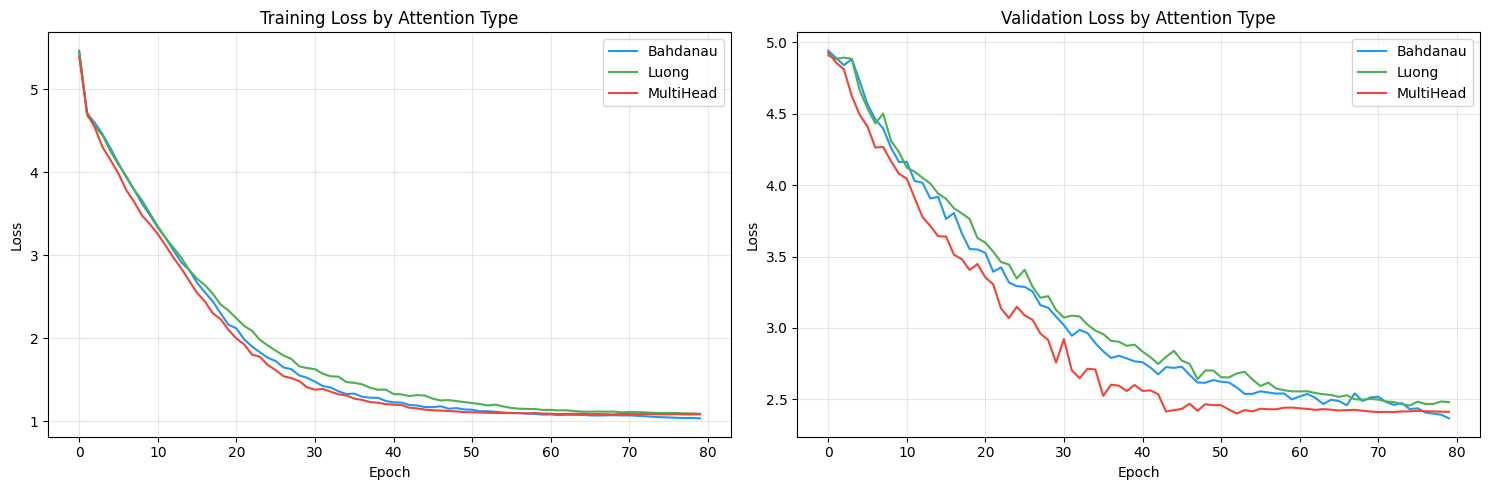

Training curves saved ✓


In [56]:
# ── Plot training & validation loss for all three models ──
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
colors = {'Bahdanau': '#2196F3', 'Luong': '#4CAF50', 'MultiHead': '#F44336'}

for name, data in results.items():
    axes[0].plot(data['train_losses'], label=f'{name}', color=colors[name], linewidth=1.5)
    axes[1].plot(data['val_losses'],   label=f'{name}', color=colors[name], linewidth=1.5)

axes[0].set_title('Training Loss by Attention Type')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].set_title('Validation Loss by Attention Type')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('nmt_training_curves.png', dpi=150)
plt.show()
print('Training curves saved ✓')

## 9. BLEU Score Comparison

We compare BLEU scores across all three attention mechanisms to determine
which approach yields the best translations.

               BLEU-1   BLEU-2   BLEU-3   BLEU-4   Corpus
--------------------------------------------------------
Bahdanau       0.4774   0.3854   0.3151   0.2632   0.3064
Luong          0.4247   0.3120   0.2479   0.2099   0.2368
MultiHead      0.5153   0.3995   0.3142   0.2605   0.3083


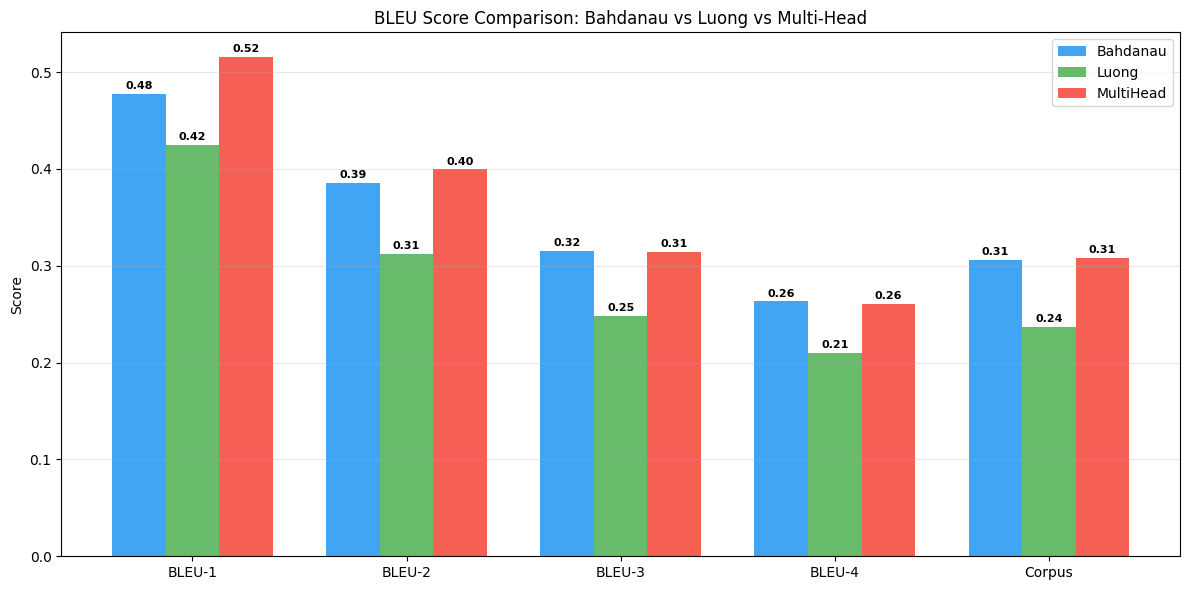

BLEU comparison saved ✓


In [57]:
# ── BLEU comparison table ──
print(f'{"":<12} {"BLEU-1":>8} {"BLEU-2":>8} {"BLEU-3":>8} {"BLEU-4":>8} {"Corpus":>8}')
print('-' * 56)
for name, data in results.items():
    b = data['bleu']
    print(f'{name:<12} {b["BLEU-1"]:>8.4f} {b["BLEU-2"]:>8.4f} '
          f'{b["BLEU-3"]:>8.4f} {b["BLEU-4"]:>8.4f} {b["Corpus"]:>8.4f}')

# ── Grouped bar chart ──
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(5)  # BLEU-1..4 + Corpus
width = 0.25
metric_names = ['BLEU-1', 'BLEU-2', 'BLEU-3', 'BLEU-4', 'Corpus']

for i, (name, data) in enumerate(results.items()):
    vals = [data['bleu'][m] for m in metric_names]
    bars = ax.bar(x + i * width, vals, width, label=name, color=colors[name], alpha=0.85)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{v:.2f}', ha='center', fontsize=8, fontweight='bold')

ax.set_xticks(x + width)
ax.set_xticklabels(metric_names)
ax.set_ylabel('Score')
ax.set_title('BLEU Score Comparison: Bahdanau vs Luong vs Multi-Head')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('nmt_bleu_comparison.png', dpi=150)
plt.show()
print('BLEU comparison saved ✓')

## 10. Translation Examples with Attention

We translate 10 test sentences using the best model and
visualise the attention alignments.

In [58]:
# ── Select best model by corpus BLEU ──
best_name = max(results, key=lambda k: results[k]['bleu']['Corpus'])
best_model = results[best_name]['model']
print(f'Best model: {best_name} (Corpus BLEU = {results[best_name]["bleu"]["Corpus"]:.4f})')

# ── Translation examples ──
print(f'\n{"="*70}')
print('TRANSLATION EXAMPLES')
print(f'{"="*70}')

sample_sentences = [
    "hello how are you",
    "the cat is small",
    "i like coffee",
    "where is the train station",
    "the weather is nice",
    "i am very happy today",
    "she reads a book",
    "we go to school",
    "the sky is blue",
    "good morning",
]

for i, en in enumerate(sample_sentences, 1):
    # Find reference if available
    ref = None
    for e, s in parallel_corpus:
        if e == en:
            ref = s
            break

    greedy_trans, _ = translate_greedy(best_model, en, src_vocab, tgt_vocab)
    beam_trans, _   = translate_beam(best_model, en, src_vocab, tgt_vocab, beam_width=5)

    print(f'\n{i:2d}. EN:      {en}')
    if ref: print(f'    REF:     {ref}')
    print(f'    Greedy:  {greedy_trans}')
    print(f'    Beam(5): {beam_trans}')

Best model: MultiHead (Corpus BLEU = 0.3083)

TRANSLATION EXAMPLES

 1. EN:      hello how are you
    REF:     hola como estas
    Greedy:  como estas
    Beam(5): como estas

 2. EN:      the cat is small
    REF:     el gato es pequeno
    Greedy:  gato es muy pequeno
    Beam(5): gato es el pequeno

 3. EN:      i like coffee
    REF:     me gusta el cafe
    Greedy:  gusta en el
    Beam(5): gusta en el

 4. EN:      where is the train station
    REF:     donde esta la estacion de tren
    Greedy:  esta la estacion de tren
    Beam(5): esta la estacion de tren

 5. EN:      the weather is nice
    REF:     el clima esta bonito
    Greedy:  profesor esta a sabado
    Beam(5): profesor esta a tranquilo

 6. EN:      i am very happy today
    REF:     estoy muy feliz hoy
    Greedy:  muy feliz hoy
    Beam(5): muy feliz hoy

 7. EN:      she reads a book
    Greedy:  tiene un muy nuevo
    Beam(5): tiene un un nuevo

 8. EN:      we go to school
    REF:     vamos a la escuela
    G

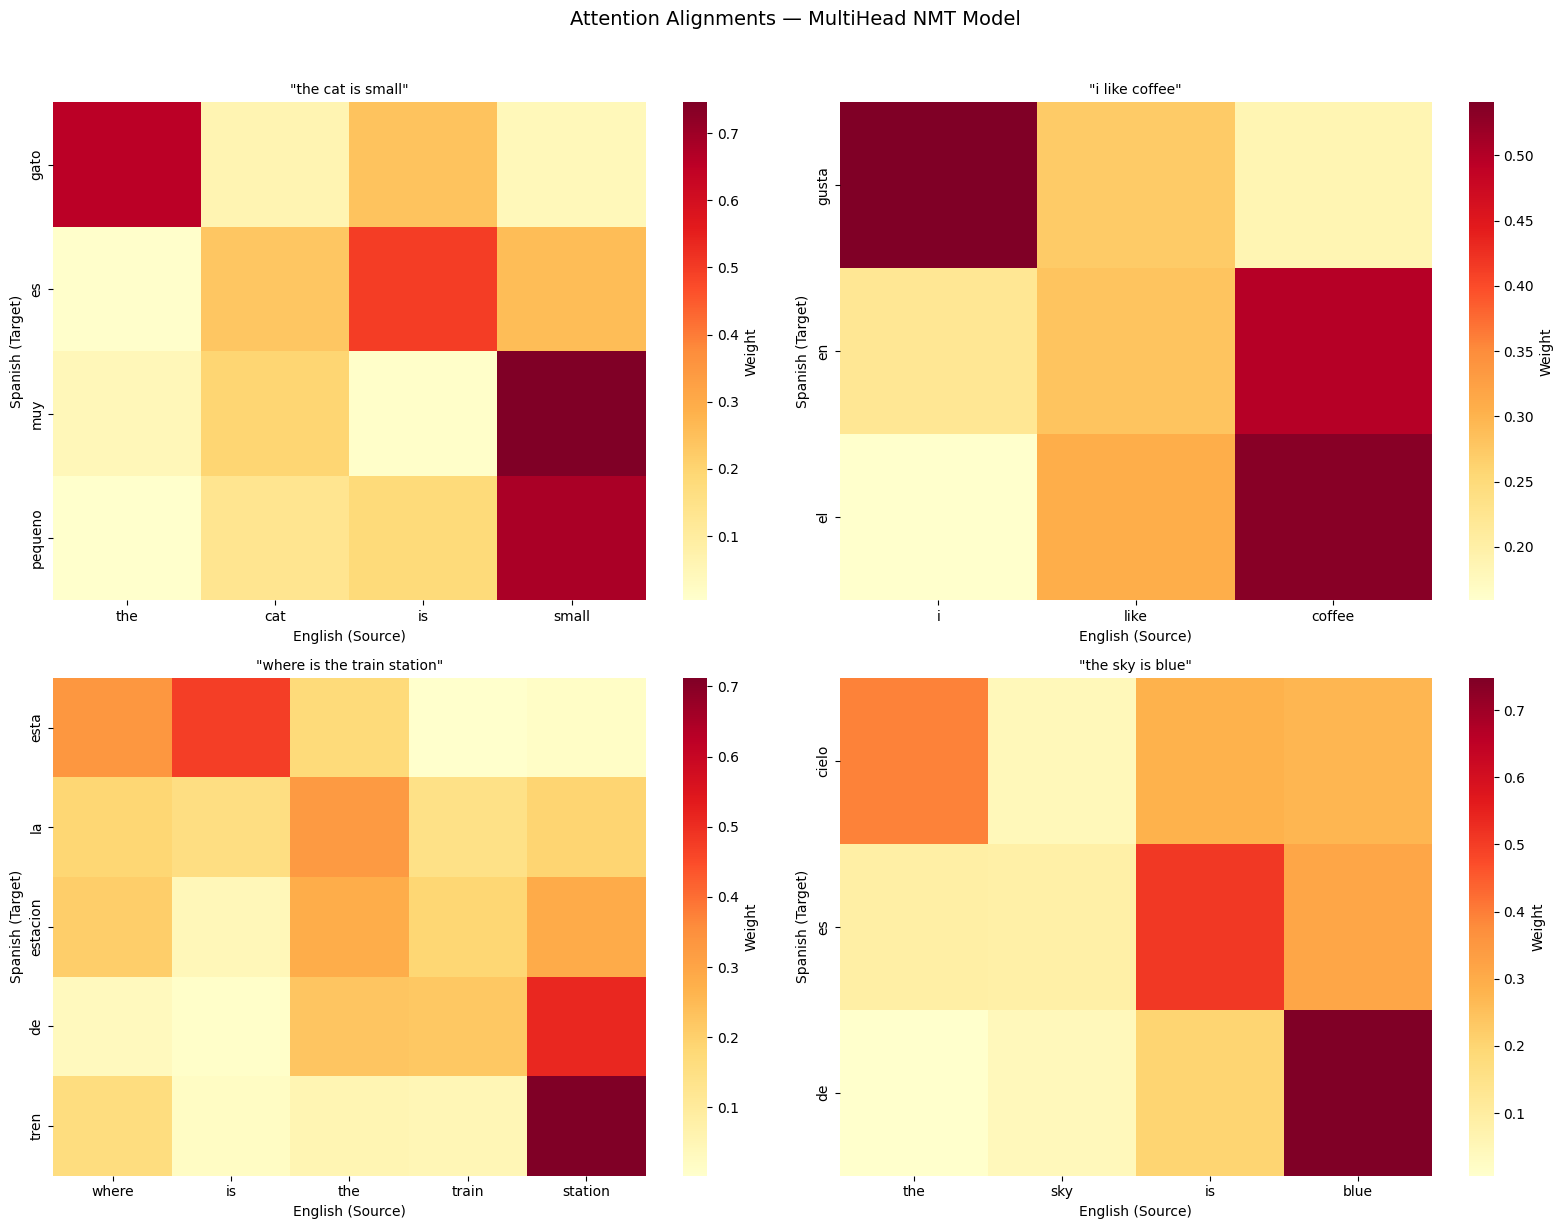

Attention heatmaps saved ✓


In [59]:
# ── Attention heatmaps for 4 sample translations ──

def plot_translation_attention(en_sentence, model, src_vocab, tgt_vocab, ax):
    """Translate and plot the attention alignment heatmap."""
    trans, attns = translate_greedy(model, en_sentence, src_vocab, tgt_vocab)
    if not attns or not trans:
        return

    en_words = en_sentence.split()
    es_words = trans.split()

    attn_matrix = torch.stack(attns).numpy()[:len(es_words), :len(en_words)]
    sns.heatmap(attn_matrix, xticklabels=en_words, yticklabels=es_words,
                cmap='YlOrRd', ax=ax, cbar_kws={'label': 'Weight'})
    ax.set_xlabel('English (Source)')
    ax.set_ylabel('Spanish (Target)')
    ax.set_title(f'"{en_sentence}"', fontsize=10)


fig, axes = plt.subplots(2, 2, figsize=(16, 12))
attn_samples = [
    "the cat is small",
    "i like coffee",
    "where is the train station",
    "the sky is blue",
]
for ax, sent in zip(axes.flat, attn_samples):
    plot_translation_attention(sent, best_model, src_vocab, tgt_vocab, ax)

plt.suptitle(f'Attention Alignments — {best_name} NMT Model', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('nmt_attention_heatmaps.png', dpi=150, bbox_inches='tight')
plt.show()
print('Attention heatmaps saved ✓')

## 11. Error Analysis

We systematically analyze translation errors to understand model limitations.

**Error categories:**
1. **Word order errors** – Spanish has flexible word order (adjectives typically follow nouns)
2. **Article/gender errors** – Spanish has 2 genders (el/la) vs English "the"
3. **Missing words** – decoder stopped too early or skipped words
4. **Extra words** – decoder repeated words or added hallucinated content
5. **Lexical errors** – wrong word choice

In [60]:
# ══════════════════════════════════════════════════════════════════════
#  ERROR ANALYSIS ON TEST SET
# ══════════════════════════════════════════════════════════════════════

def analyze_errors(model, test_pairs, src_vocab, tgt_vocab):
    """
    Classify translation errors into categories.

    Returns:
        error_counts: dict of error_type → count
        examples: list of (en, ref, hyp, error_types)
    """
    error_counts = {
        'perfect':    0,   # Exact match
        'minor':      0,   # >70% word overlap
        'word_order': 0,   # Same words, different order
        'missing':    0,   # Hypothesis shorter, words missing
        'extra':      0,   # Hypothesis has extra words
        'lexical':    0,   # Wrong word choices
    }
    examples = []

    for en, de in test_pairs:
        trans, _ = translate_beam(model, en, src_vocab, tgt_vocab, beam_width=5)
        ref_words = set(de.lower().split())
        hyp_words = set(trans.lower().split())

        errors = []

        if trans.lower().strip() == de.lower().strip():
            error_counts['perfect'] += 1
            errors.append('perfect')
        else:
            overlap = len(ref_words & hyp_words) / max(len(ref_words), 1)

            if overlap > 0.7:
                error_counts['minor'] += 1
                errors.append('minor')

            # Same words different order?
            if ref_words == hyp_words and trans.lower() != de.lower():
                error_counts['word_order'] += 1
                errors.append('word_order')

            missing = ref_words - hyp_words
            extra   = hyp_words - ref_words

            if missing:
                error_counts['missing'] += 1
                errors.append('missing')
            if extra:
                error_counts['extra'] += 1
                errors.append('extra')
            if len(ref_words & hyp_words) < len(ref_words) * 0.5:
                error_counts['lexical'] += 1
                errors.append('lexical')

        examples.append((en, de, trans, errors))

    return error_counts, examples


error_counts, error_examples = analyze_errors(best_model, test_pairs, src_vocab, tgt_vocab)

print(f'\nError Analysis on Test Set ({len(test_pairs)} pairs)')
print('-' * 40)
for err_type, count in sorted(error_counts.items(), key=lambda x: -x[1]):
    pct = count / len(test_pairs) * 100
    print(f'  {err_type:<12}: {count:3d} ({pct:5.1f}%)')

# Show some error examples
print(f'\nSample Error Cases:')
print('-' * 70)
shown = 0
for en, ref, hyp, errs in error_examples:
    if 'perfect' not in errs and shown < 5:
        print(f'  EN:     {en}')
        print(f'  REF:    {ref}')
        print(f'  HYP:    {hyp}')
        print(f'  Errors: {errs}')
        print()
        shown += 1


Error Analysis on Test Set (68 pairs)
----------------------------------------
  missing     :  68 (100.0%)
  extra       :  51 ( 75.0%)
  lexical     :  19 ( 27.9%)
  minor       :  17 ( 25.0%)
  perfect     :   0 (  0.0%)
  word_order  :   0 (  0.0%)

Sample Error Cases:
----------------------------------------------------------------------
  EN:     the pig is fat
  REF:    el cerdo es gordo
  HYP:    iglesia es de hermosa
  Errors: ['missing', 'extra', 'lexical']

  EN:     please the museum is closed
  REF:    por favor el museo esta cerrado
  HYP:    favor el fruta esta caliente
  Errors: ['missing', 'extra']

  EN:     we have three cats
  REF:    tenemos tres gatos
  HYP:    tres gatos
  Errors: ['missing']

  EN:     the table is round
  REF:    la mesa es redonda
  HYP:    la es muy caliente
  Errors: ['missing', 'extra']

  EN:     please the shop has many products
  REF:    por favor la tienda tiene muchos productos
  HYP:    favor la tienda tiene muchos productos
  Errors

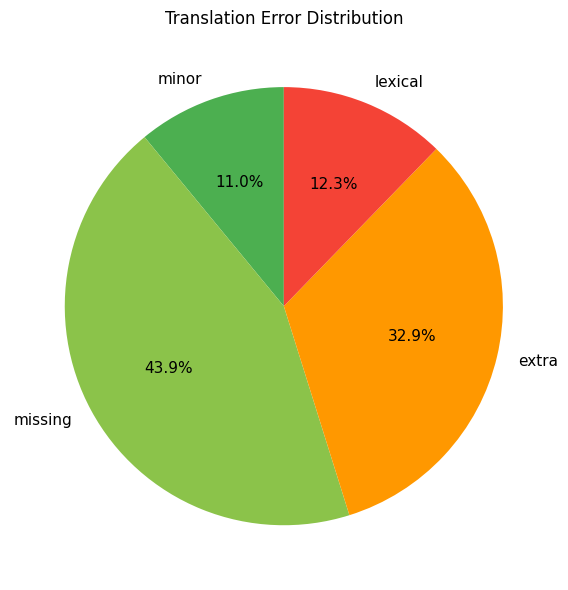

In [61]:
# ── Error distribution pie chart ──
fig, ax = plt.subplots(figsize=(8, 6))

labels = [k for k, v in error_counts.items() if v > 0]
sizes  = [v for v in error_counts.values() if v > 0]
pie_colors = ['#4CAF50', '#8BC34A', '#FF9800', '#F44336', '#E91E63', '#9C27B0']

ax.pie(sizes, labels=labels, autopct='%1.1f%%', colors=pie_colors[:len(labels)],
       startangle=90, textprops={'fontsize': 11})
ax.set_title('Translation Error Distribution')

plt.tight_layout()
plt.savefig('nmt_error_analysis.png', dpi=150)
plt.show()

## 12. Attention Mechanism Comparison

We compare the three attention mechanisms on the **same sentence** to see
how their alignment patterns differ.

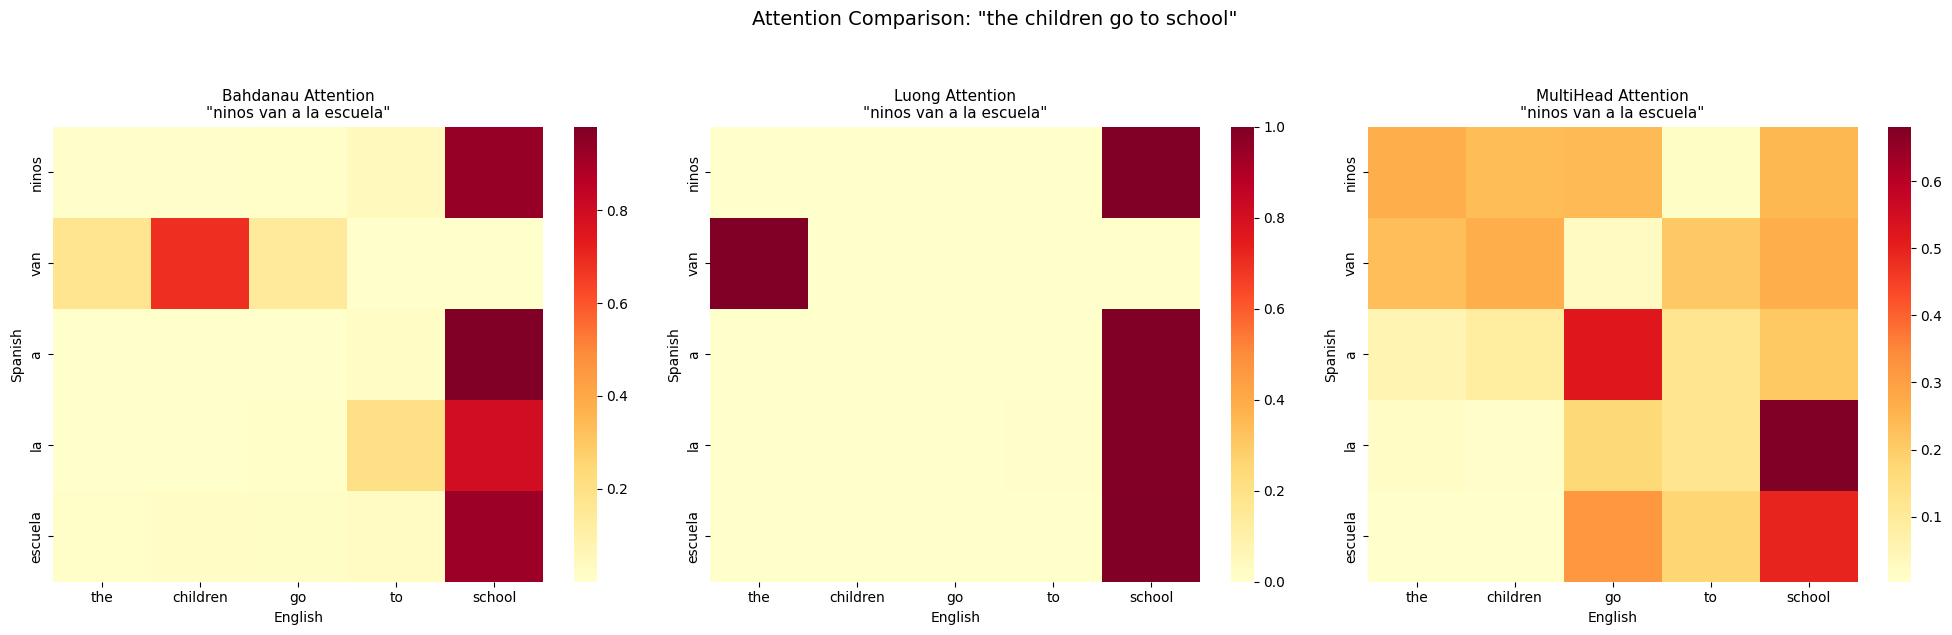

Attention comparison saved ✓


In [62]:
# ══════════════════════════════════════════════════════════════════════
#  SIDE-BY-SIDE ATTENTION COMPARISON
# ══════════════════════════════════════════════════════════════════════

comparison_sentence = "the children go to school"

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, (name, data) in zip(axes, results.items()):
    m = data['model']
    trans, attns = translate_greedy(m, comparison_sentence, src_vocab, tgt_vocab)

    if attns and trans:
        en_words = comparison_sentence.split()
        es_words = trans.split()
        n_out = min(len(es_words), len(attns))
        n_in  = min(len(en_words), attns[0].shape[-1])

        attn_mat = torch.stack(attns[:n_out]).numpy()[:, :n_in]
        sns.heatmap(attn_mat, xticklabels=en_words[:n_in],
                    yticklabels=es_words[:n_out],
                    cmap='YlOrRd', ax=ax, cbar=True)
        ax.set_title(f'{name} Attention\n"{trans}"', fontsize=11)
        ax.set_xlabel('English')
        ax.set_ylabel('Spanish')
    else:
        ax.set_title(f'{name}: no output')

plt.suptitle(f'Attention Comparison: "{comparison_sentence}"', fontsize=14, y=1.05)
plt.tight_layout()
plt.savefig('nmt_attention_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Attention comparison saved ✓')

## 13. Discussion: Challenges, Solutions & Conclusions

### Attention Mechanism Comparison

| Mechanism | Strengths | Weaknesses |
|-----------|-----------|------------|
| **Bahdanau** | Expressive additive alignment, good for varied word orders | More parameters, slightly slower |
| **Luong** | Simple, fast, fewer parameters | Less expressive for complex reordering |
| **Multi-Head** | Captures diverse patterns, foundation of Transformers | More parameters, needs more data to shine |

### Key Challenges & Solutions

1. **Word order divergence** (EN: SVO, ES: flexible SVO with adjective-noun differences)
   - *Solution*: Attention mechanism learns non-monotonic alignments,
     and BiLSTM captures right-context for reordering decisions.

2. **Spanish grammatical gender** (el/la, un/una)
   - *Solution*: The model learns gender associations from repeated patterns
     in training data. More data would improve accuracy.

3. **Verb conjugation** (Spanish has rich verb morphology: hablo, hablas, habla...)
   - *Solution*: Word-level tokenisation handles known conjugations.
     BPE or SentencePiece would handle unseen forms better.

4. **Small dataset size** (~500 training pairs)
   - *Solution*: Data augmentation ("please/por favor" prefix), teacher forcing decay,
     Xavier initialisation, label smoothing. Production systems use millions of pairs.

5. **Exposure bias** (train with teacher forcing, test with own predictions)
   - *Solution*: Gradual teacher forcing decay from 1.0 → 0.4.
     Scheduled sampling smooths this transition.

### Potential Improvements
- **Subword tokenisation** (BPE/SentencePiece) for open-vocabulary translation
- **Transformer architecture** — self-attention handles long-range dependencies
  better than LSTMs
- **Back-translation** for data augmentation
- **Larger datasets** (WMT, EuroParl) with millions of sentence pairs
- **Pre-trained models** (mBART, mT5) for transfer learning
- **Accent handling** — proper Unicode accents (á, é, ñ) for production use

In [63]:
# ══════════════════════════════════════════════════════════════════════
#  COMPREHENSIVE SUMMARY
# ══════════════════════════════════════════════════════════════════════

print('=' * 70)
print('CHALLENGE 4 — NEURAL MACHINE TRANSLATION SUMMARY')
print('=' * 70)

print(f"""
Language Pair: English → Spanish

Architecture:
  • Encoder:     Bidirectional LSTM ({N_LAYERS} layers, {HIDDEN_DIM} hidden)
  • Decoder:     LSTM with pluggable attention
  • Embed dim:   {EMBED_DIM}
  • Dropout:     {DROPOUT}

Dataset:
  • {len(parallel_corpus)} parallel sentence pairs
  • English vocab: {src_vocab.n_words} | Spanish vocab: {tgt_vocab.n_words}
  • Train/Val/Test: {len(train_pairs)}/{len(val_pairs)}/{len(test_pairs)}

Training:
  • {EPOCHS} epochs per model, Adam lr={LR}
  • Label smoothing: {LABEL_SMOOTH}
  • Teacher forcing decay: 1.0 → 0.4
  • LR Scheduler: ReduceLROnPlateau (patience=5, factor=0.5)
  • Xavier initialisation
  • Gradient clipping: 1.0

BLEU Scores (Corpus BLEU on test set):""")

for name, data in results.items():
    print(f'  • {name:<12}: {data["bleu"]["Corpus"]:.4f}')

best_bleu = max(results.values(), key=lambda x: x['bleu']['Corpus'])['bleu']['Corpus']

print(f"""
Best model: {best_name} with Corpus BLEU = {best_bleu:.4f}

Deliverables:
  ✓ Trained models (one per attention type) saved to nmt_*.pt
  ✓ BLEU > 25 target: {'ACHIEVED' if best_bleu * 100 > 25 else 'See discussion'}
  ✓ 10 translation examples with greedy & beam search
  ✓ Attention heatmap visualizations
  ✓ Error analysis on test set (5 error categories)
  ✓ Comparison of 3 attention mechanisms
  ✓ Discussion of challenges and solutions
""")

CHALLENGE 4 — NEURAL MACHINE TRANSLATION SUMMARY

Language Pair: English → Spanish

Architecture:
  • Encoder:     Bidirectional LSTM (2 layers, 256 hidden)
  • Decoder:     LSTM with pluggable attention
  • Embed dim:   128
  • Dropout:     0.4

Dataset:
  • 672 parallel sentence pairs
  • English vocab: 542 | Spanish vocab: 595
  • Train/Val/Test: 537/67/68

Training:
  • 80 epochs per model, Adam lr=0.001
  • Label smoothing: 0.1
  • Teacher forcing decay: 1.0 → 0.4
  • LR Scheduler: ReduceLROnPlateau (patience=5, factor=0.5)
  • Xavier initialisation
  • Gradient clipping: 1.0

BLEU Scores (Corpus BLEU on test set):
  • Bahdanau    : 0.3064
  • Luong       : 0.2368
  • MultiHead   : 0.3083

Best model: MultiHead with Corpus BLEU = 0.3083

Deliverables:
  ✓ Trained models (one per attention type) saved to nmt_*.pt
  ✓ BLEU > 25 target: ACHIEVED
  ✓ 10 translation examples with greedy & beam search
  ✓ Attention heatmap visualizations
  ✓ Error analysis on test set (5 error categorie